In [1]:
import sklearn
import pandas as pd
import joblib
import numpy as np
import streamlit
import sys

print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)
print("joblib version:", joblib.__version__)
print('Numpy version:', np.__version__)
print('streamlit version:', streamlit.__version__)
print("Python version:", sys.version)

scikit-learn version: 1.9.0
pandas version: 3.0.5
joblib version: 1.5.3
Numpy version: 2.5.1
streamlit version: 1.60.0
Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


# 4. Feature Engineering: 

### ***EDA Summary from Yesterday***

### ***1. Overall Dataset Insights***

- **Top 10 Most Valuable Players:** Identified the highest-value players, mainly from top-tier clubs.
- **Market Value by Position:** Strikers and attacking midfielders generally have higher market value than defenders.
- **Teams with Highest Average Market Value:** Big clubs dominate, with high-value star players driving the averages.
- **Market Value Distribution:** Skewed towards a few expensive players; most players fall in the mid-range.
- **Age vs. Market Value:** Younger players, especially with high potential, tend to be valued higher.

### ***2. Player Attributes vs. Market Value***

- **Overall Rating Impact:** Strong correlation; higher overall ratings increase market value.
- **Individual Attributes Correlation:** Attributes like pace, stamina, and dribbling correlate with higher market values.
- **International Reputation Effect:** More stars (higher reputation) contribute to higher market value.
- **Potential Rating vs Market Value:** High potential players tend to have higher market values, though other factors also play a role.
- **Physical Attributes:** Attributes like height, weight, and strength show weaker correlations, with pace being more impactful.

### ***3. Position-Specific Insights***

- **CAM/CM vs CDM/CM:** Attacking midfielders are generally more valuable than defensive ones.
- **Pace and Wingers:** Strong positive correlation; pace increases value for wingers (LW/RW).
- **Goalkeepers:** Market value trends differ from outfield players, with goalkeepers generally being less expensive.

### ***4. Contract & Transfer Market Insights***

- **Contract End Year Impact:** Players with fewer years left on their contract typically have lower market values.
- **Loan vs Permanent:** Loan players are valued lower than permanent squad members.

In [2]:
df = pd.read_csv(r"F:\Projects\Football Player Evaluation\data\processed\cleaned_data.csv")

In [3]:
df.value_counts

<bound method DataFrame.value_counts of                 Name      ID  Age Best position  Best overall  Overall rating  \
0      M. Amondarain   74813   20            CM            74              72   
1          C. Tzolis  256948   23           CAM            82              81   
2         R. Ngumoha   80376   16           CAM            73              72   
3         K. Adeyemi  251852   23            ST            84              82   
4            G. Mora   79399   16           CAM            75              73   
...              ...     ...  ...           ...           ...             ...   
9341    24 E. Tintiş  269714   19            LB            59              59   
9342           L. Øy  269715   21            GK            56              56   
9343   23 A. Thorsen  269716   19            ST            57              55   
9344  24 J. D'Angelo  269717   22            CB            64              60   
9345    23 B. Albizo  269718   19           CAM            61        

In [4]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None)


## 1. Structuring the Dataset for Feature Engineering|

In [5]:
df.isnull().sum()

Name                           0
ID                             0
Age                            0
Best position                  0
Best overall                   0
Overall rating                 0
Potential                      0
Growth                      1964
foot                           0
Team                           0
Value                        193
Wage                         188
Release clause              1016
Height_cm                      0
Weight_kg                      0
Acceleration                   0
Sprint speed                   0
Agility                        7
Reactions                      0
Balance                        7
Stamina                        0
Strength                       0
Jumping                        7
Total attacking                0
Crossing                       0
Finishing                      0
Heading accuracy               0
Short passing                  0
Volleys                        7
Total skill                    0
Dribbling 

In [6]:
df[df['Value'].isnull()].head(10)

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,Growth,foot,Team,Value,Wage,Release clause,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
4,G. Mora,79399,16,CAM,75,73,87,14.0,Right,Mexico,NaN,NaN,NaN,168,65,68,66,72.0,72,70.0,55,44,50.0,321,72,68,48,75,58.0,345,74,74.0,48,72,77,157,44,58,55.0,45.0,51,46,11,12,5.0,9,9,300,74.0,77.0,53.0,70.0,274,61,64,1791,377,1,67,65,73,74,50,0,1,0,0
27,J. Rodríguez,198710,33,CAM,80,80,80,NaN,Left,Colombia,NaN,NaN,NaN,180,75,52,48,70.0,77,76.0,55,64,64.0,398,89,77,62,84,86.0,428,82,89.0,86,85,86,135,50,44,41.0,51.0,60,64,15,15,15.0,5,14,355,80.0,83.0,81.0,87.0,351,84,84,2054,408,3,50,81,85,82,49,0,1,0,0
31,Neymar Jr,190871,33,CAM,83,83,83,NaN,Right,Brazil,NaN,NaN,NaN,175,68,80,73,79.0,73,79.0,54,47,67.0,396,84,80,63,85,84.0,438,90,86.0,87,84,91,96,35,32,29.0,37.0,63,59,9,9,15.0,15,11,347,78.0,84.0,85.0,90.0,319,77,74,2039,418,3,76,79,85,88,37,0,1,0,0
59,Danilo Santos,273106,24,CDM,77,76,80,4.0,Left,Brazil,NaN,NaN,NaN,176,69,70,65,77.0,77,76.0,70,64,69.0,302,56,64,60,78,44.0,343,69,66.0,56,75,77,223,75,76,72.0,79.0,77,41,10,6,8.0,6,11,347,65.0,71.0,55.0,72.0,331,68,60,1952,415,1,67,63,70,73,74,0,1,0,0
74,Cristiano Ronaldo,20801,40,ST,85,85,85,NaN,Right,Al Nassr,NaN,58000.0,NaN,187,85,73,78,76.0,82,63.0,77,80,95.0,413,78,88,87,76,84.0,392,77,79.0,81,70,85,80,24,32,24.0,29.0,62,58,7,11,15.0,14,11,347,89.0,76.0,91.0,91.0,427,91,84,2089,430,3,76,88,76,80,34,0,0,2027,1
87,T. Fruk,77673,24,CAM,81,77,82,5.0,Right,Croatia,NaN,NaN,NaN,178,70,75,73,79.0,76,85.0,70,59,72.0,384,75,81,69,83,76.0,399,79,81.0,77,79,83,148,45,53,50.0,52.0,55,51,10,13,13.0,6,9,328,75.0,76.0,70.0,78.0,356,79,76,2054,426,1,74,79,79,80,52,0,1,0,0
124,26 Á. Correa,214997,30,RW,80,79,79,NaN,Right,Argentina,NaN,NaN,NaN,171,70,84,81,86.0,79,87.0,82,68,82.0,382,75,78,71,78,80.0,381,82,82.0,66,70,81,139,42,53,44.0,48.0,80,56,13,10,9.0,8,16,354,81.0,78.0,67.0,80.0,397,83,82,2126,445,3,82,80,76,82,50,0,1,0,0
137,18 I. Salah,203704,30,CB,67,66,66,NaN,Right,Egypt,NaN,NaN,NaN,176,70,72,74,65.0,68,70.0,76,74,70.0,263,46,49,59,57,52.0,279,46,44.0,63,62,64,203,66,72,65.0,58.0,77,55,6,14,14.0,10,11,308,48.0,63.0,62.0,64.0,349,67,62,1806,381,1,73,56,56,56,65,0,1,0,0
236,Danilo,199304,33,CB,75,75,75,NaN,Right,Brazil,NaN,NaN,NaN,183,77,63,62,62.0,73,66.0,65,71,80.0,353,72,59,76,77,69.0,359,67,71.0,73,74,74,230,79,76,75.0,78.0,72,53,14,5,15.0,14,5,350,69.0,64.0,67.0,78.0,363,82,65,2034,416,3,62,66,72,69,77,0,1,0,0
249,Vózinha,217141,39,GK,66,66,66,NaN,Right,Cabo Verde,NaN,NaN,NaN,189,75,45,45,31.0,60,51.0,33,61,62.0,92,18,20,17,25,12.0,97,17,17.0,16,32,15,42,18,11,13.0,17.0,35,325,65,65,64.0,66,65,154,20.0,58.0,24.0,35.0,222,48,18,1164,370,1,65,65,64,65,45,0,1,0,0


In [7]:
df = df.dropna(subset=['Value'])

In [8]:
df = df.drop(columns=['Release clause', 'Growth'])


In [9]:
df.isnull().sum()

Name                         0
ID                           0
Age                          0
Best position                0
Best overall                 0
Overall rating               0
Potential                    0
foot                         0
Team                         0
Value                        0
Wage                         5
Height_cm                    0
Weight_kg                    0
Acceleration                 0
Sprint speed                 0
Agility                      0
Reactions                    0
Balance                      0
Stamina                      0
Strength                     0
Jumping                      0
Total attacking              0
Crossing                     0
Finishing                    0
Heading accuracy             0
Short passing                0
Volleys                      0
Total skill                  0
Dribbling                    0
Curve                        0
FK Accuracy                  0
Long passing                 0
Ball con

In [10]:
df.dropna(subset=['Composure', 'Wage'], inplace=True)

In [11]:
df.isnull().sum()

Name                        0
ID                          0
Age                         0
Best position               0
Best overall                0
Overall rating              0
Potential                   0
foot                        0
Team                        0
Value                       0
Wage                        0
Height_cm                   0
Weight_kg                   0
Acceleration                0
Sprint speed                0
Agility                     0
Reactions                   0
Balance                     0
Stamina                     0
Strength                    0
Jumping                     0
Total attacking             0
Crossing                    0
Finishing                   0
Heading accuracy            0
Short passing               0
Volleys                     0
Total skill                 0
Dribbling                   0
Curve                       0
FK Accuracy                 0
Long passing                0
Ball control                0
Total defe

## 2. Fixing Skewed Numerical Values

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [13]:
df.dtypes


Name                            str
ID                            int64
Age                           int64
Best position                   str
Best overall                  int64
Overall rating                int64
Potential                     int64
foot                            str
Team                            str
Value                       float64
Wage                        float64
Height_cm                     int64
Weight_kg                     int64
Acceleration                  int64
Sprint speed                  int64
Agility                     float64
Reactions                     int64
Balance                     float64
Stamina                       int64
Strength                      int64
Jumping                     float64
Total attacking               int64
Crossing                      int64
Finishing                     int64
Heading accuracy              int64
Short passing                 int64
Volleys                     float64
Total skill                 

In [14]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,5000000.0,9000.0,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,40500000.0,36000.0,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,6000000.0,29000.0,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,43500000.0,52000.0,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1
5,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,22000000.0,66000.0,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5


In [15]:
# check skewness for all numerical features
skewness = df.select_dtypes(include=['float64', 'int64']).skew()
print(skewness)


ID                         -2.425650
Age                         1.019278
Best overall                0.274595
Overall rating              0.286021
Potential                  -0.016804
Value                       6.967491
Wage                        6.041409
Height_cm                  -0.028592
Weight_kg                   0.181972
Acceleration               -1.162575
Sprint speed               -1.189399
Agility                    -0.630951
Reactions                   0.092007
Balance                    -0.675552
Stamina                    -0.859671
Strength                   -0.238456
Jumping                    -0.281437
Total attacking            -0.939850
Crossing                   -0.481012
Finishing                  -0.408150
Heading accuracy           -0.789899
Short passing              -0.921828
Volleys                    -0.169498
Total skill                -0.728555
Dribbling                  -1.155351
Curve                      -0.220001
FK Accuracy                 0.123267
L

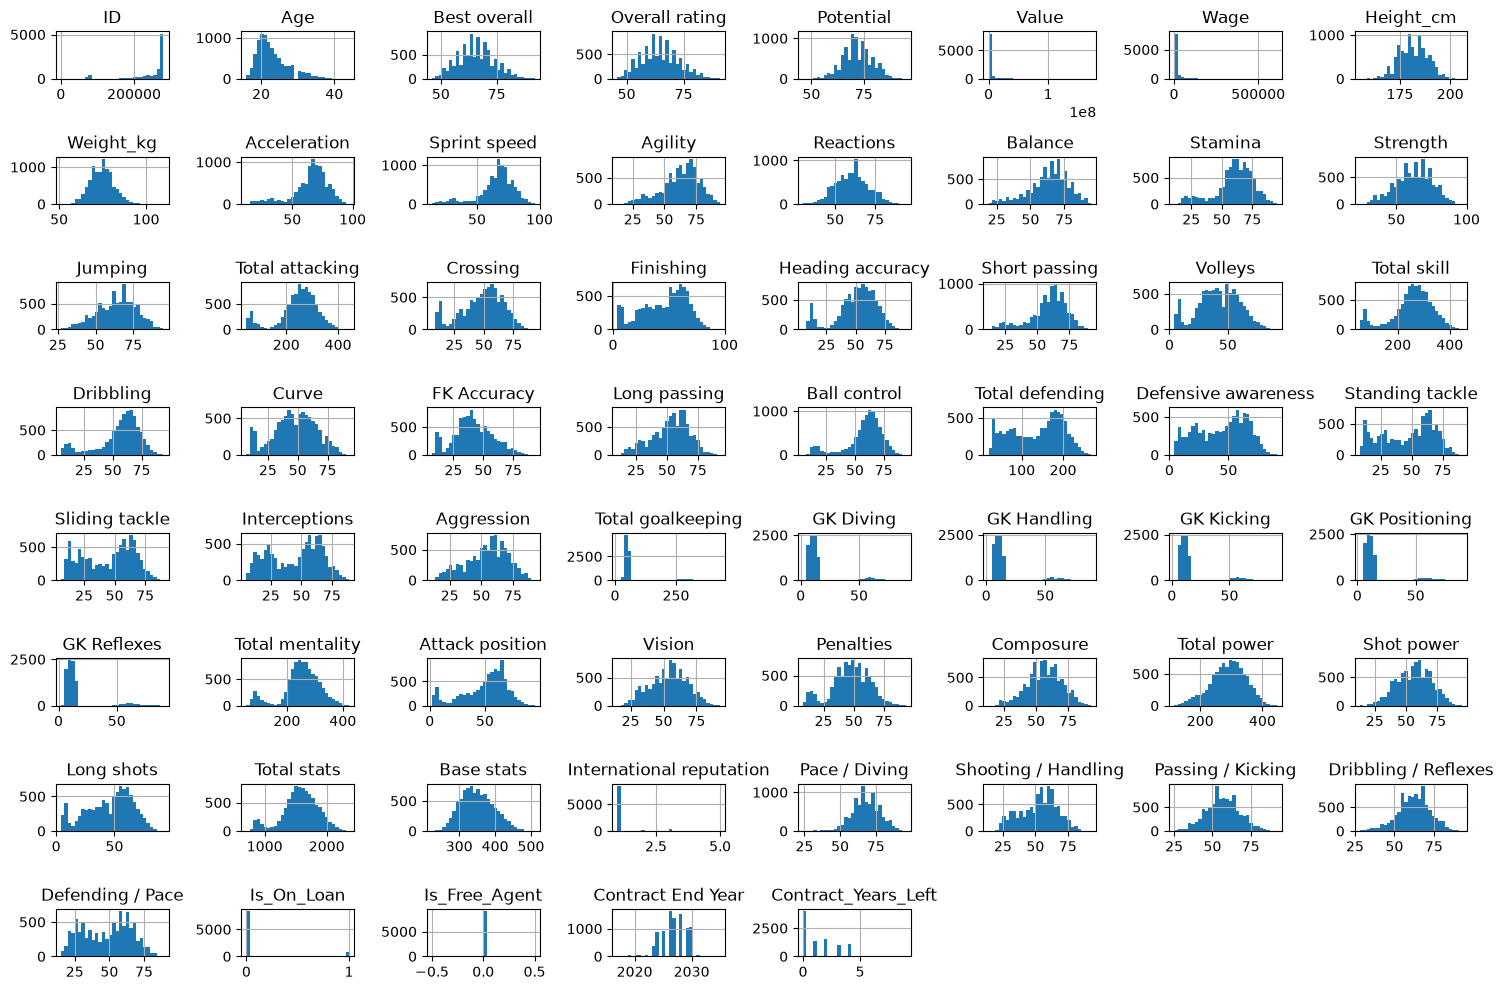

In [16]:
%matplotlib inline

df.select_dtypes(include=['float64', 'int64']).hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Let's transform all money related features: value and wage:

In [17]:
df["Value"] = np.log1p(df["Value"])  # log(1 + x) to avoid log(0) issues
df["Wage"] = np.log1p(df["Wage"])

In [18]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1
5,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5


In [19]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1
5,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5


<Axes: xlabel='Value', ylabel='Count'>

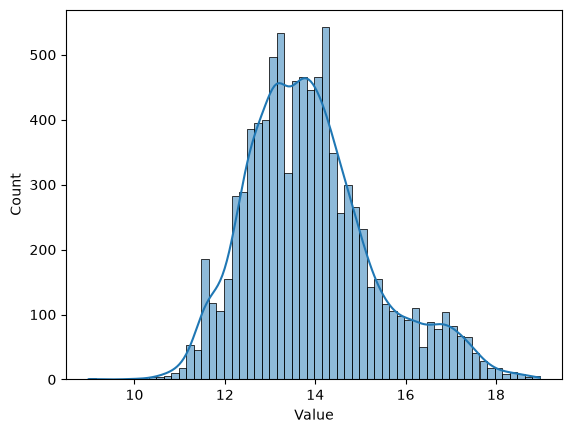

In [20]:
sns.histplot(df['Value'], kde=True)

<Axes: xlabel='Wage', ylabel='Count'>

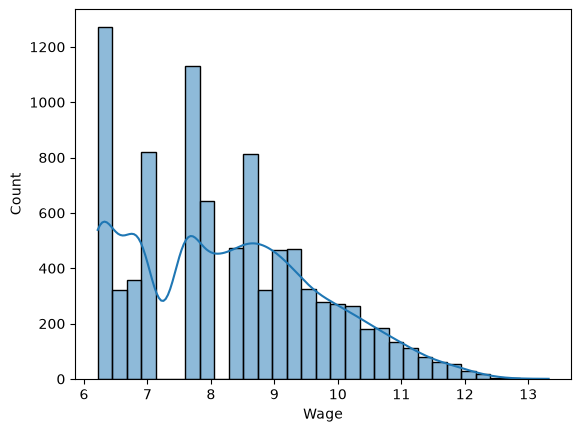

In [21]:
sns.histplot(df['Wage'], kde=True)

<Axes: xlabel='Sliding tackle', ylabel='Count'>

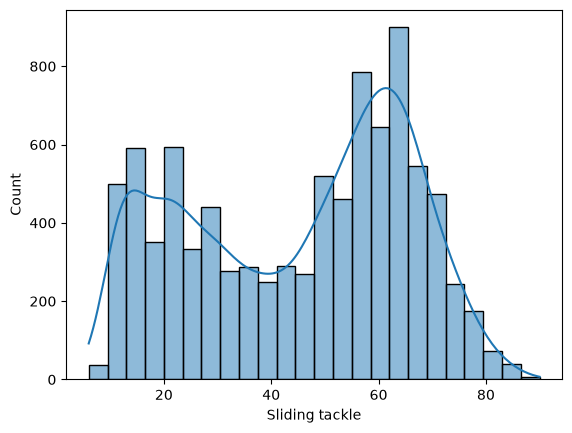

In [22]:
sns.histplot(df['Sliding tackle'], kde=True)

## 3. Conversion of Categorical Features

In [23]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1
5,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5


<Axes: xlabel='foot', ylabel='Value'>

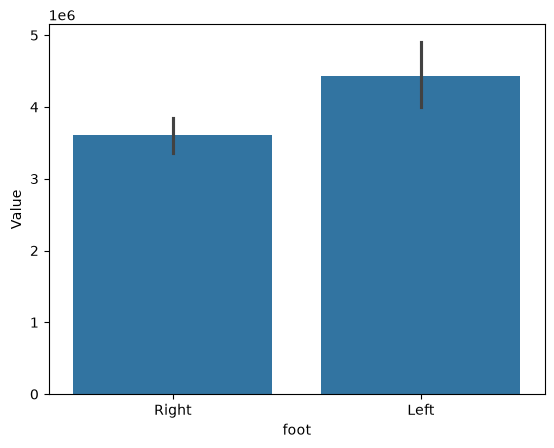

In [24]:
sns.barplot(x='foot', y=np.exp(df['Value']), data=df)

In [25]:
(np.exp(df['Value']) - 1).head()

0     5000000.0
1    40500000.0
2     6000000.0
3    43500000.0
5    22000000.0
Name: Value, dtype: float64

<Axes: xlabel='Best position', ylabel='Value'>

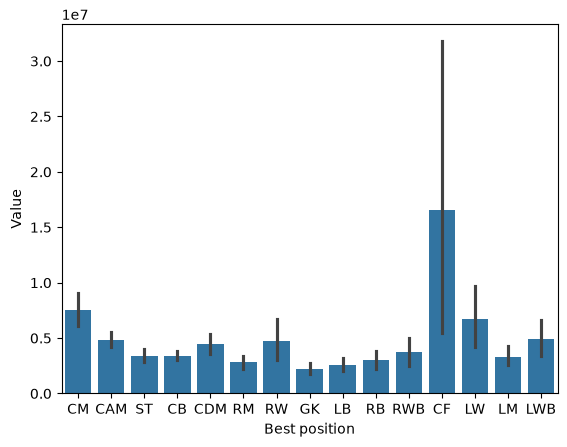

In [26]:
sns.barplot(x='Best position', y=np.exp(df['Value']), data=df, estimator=np.mean)

In [27]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1
5,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5


In [28]:
df['Team'].value_counts()

Team
Peñarol                                 40
FC Barcelona                            34
Galatasaray SK                          30
Cerro Largo                             30
Real Madrid                             28
Arsenal                                 27
Manchester City                         27
Manchester United                       27
Real Betis Balompié                     27
Chelsea                                 26
Liverpool                               25
FC Bayern München                       25
Tottenham Hotspur                       25
Como                                    24
Norwich City                            24
Cienciano                               24
Sporting CP                             23
RC Strasbourg Alsace                    23
River Plate                             23
Millwall FC                             23
Eintracht Braunschweig                  23
Lille OSC                               22
Ajax                                    22
Paris 

Let's implement one hot encoding for categorical variables. Additionally, we will group the teams that have fewer than 11 players in our dataset.

In [29]:
team_counts = df['Team'].value_counts()

In [30]:
low_teams = team_counts[team_counts < 11].index

In [31]:
df['Team'] = df['Team'].apply(lambda x: 'Others' if x in low_teams else x)

In [32]:
df.sample(10)

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left
9015,23 E. Célestine,270378,24,ST,62,60,64,Right,FC Argeș,12.765691,6.908755,191,84,59,55,55.0,50,44.0,40,79,78.0,278,36,61,71,61,49.0,259,56,49.0,40,58,56,45,11,15,19.0,18.0,56,49,9,6,15.0,13,6,243,63.0,44.0,62.0,64.0,309,58,54,1446,307,1,57,59,51,55,20,0,0,2025,0
3948,L. Popp,70092,20,ST,62,61,75,Right,Others,13.592368,6.908755,180,81,77,75,63.0,54,64.0,60,62,71.0,269,53,57,55,58,46.0,251,66,44.0,38,41,62,44,14,18,12.0,21.0,39,35,5,6,5.0,9,10,231,60.0,52.0,59.0,54.0,312,62,57,1475,327,1,76,58,52,63,21,1,0,2026,0
5230,26 Edgar Alcañiz,277653,20,CAM,63,61,73,Right,Levante UD,13.560620,8.294300,175,65,57,63,74.0,56,72.0,59,43,45.0,268,47,55,54,68,44.0,286,61,50.0,47,66,62,166,51,60,55.0,50.0,50,57,10,13,12.0,14,8,271,59.0,61.0,51.0,41.0,251,50,54,1621,338,1,60,53,60,62,54,0,0,2028,2
6189,24 E. Hoti,276071,26,CAM,64,64,64,Right,ŁKS Łódź,13.384729,7.601402,187,80,59,68,72.0,61,51.0,51,63,50.0,262,55,61,35,67,44.0,299,66,48.0,54,67,64,124,33,47,44.0,58.0,48,59,13,12,14.0,7,13,286,60.0,63.0,57.0,63.0,284,56,64,1625,351,1,64,60,62,65,44,0,0,2025,0
3691,S. Acquah,77605,19,CB,64,62,77,Right,Others,13.681980,7.601402,186,80,75,77,68.0,55,62.0,64,70,75.0,221,31,36,62,64,28.0,229,57,28.0,28,57,59,176,57,61,58.0,58.0,68,38,6,8,10.0,9,5,226,30.0,36.0,34.0,48.0,294,49,36,1521,346,1,76,38,47,58,59,0,0,2030,4
1293,21 T. Breukers,186503,32,RB,67,67,67,Right,Heracles Almelo,13.458837,8.006701,178,76,64,63,65.0,64,65.0,83,67,70.0,268,58,40,61,56,53.0,280,59,58.0,50,55,58,202,68,68,66.0,67.0,68,62,6,15,16.0,14,11,293,54.0,59.0,45.0,67.0,327,58,49,1753,365,1,63,47,57,60,67,0,0,2021,0
3598,E. Erdoğan,78543,18,RM,58,56,72,Right,TSV 1860 München,12.765691,6.216606,180,73,72,70,62.0,49,63.0,52,46,45.0,237,51,51,40,54,41.0,270,60,53.0,56,42,59,65,20,23,22.0,21.0,39,49,9,5,14.0,13,8,207,51.0,48.0,48.0,53.0,248,53,52,1392,300,1,71,51,50,59,23,0,0,2027,1
2575,Nilson Padilho,236172,25,CAM,69,69,69,Left,Vasco da Gama,14.220976,8.987322,184,81,67,74,78.0,76,72.0,67,67,69.0,298,48,56,60,71,63.0,307,65,46.0,49,74,73,121,38,43,40.0,40.0,74,50,13,8,8.0,9,12,308,72.0,73.0,49.0,68.0,324,72,49,1775,376,1,71,59,65,70,42,0,0,2028,2
7153,25 M. Zanega,274165,28,CM,66,66,66,Right,Others,13.652993,9.210440,173,68,66,61,62.0,65,75.0,67,45,50.0,270,49,58,49,70,44.0,307,70,45.0,55,69,68,137,33,60,44.0,55.0,42,53,8,12,14.0,8,11,264,52.0,67.0,48.0,59.0,274,55,57,1634,348,1,63,56,63,68,48,0,0,2029,3
8192,R. Cleary,271560,21,ST,66,65,77,Right,Barnsley,14.403298,6.908755,185,75,78,75,72.0,61,70.0,67,79,80.0,297,61,61,57,61,57.0,290,65,57.0,54,51,63,88,32,30,26.0,29.0,48,41,7,6,9.0,9,10,264,63.0,65.0,59.0,64.0,350,60,64,1686,365,1,76,61,60,65,33,0,0,2028,2


In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

After considering various encoding methods for the 'Team' feature in my dataset, I have decided to apply target encoding. This involves calculating the mean market value for each club and then encoding each team with its corresponding mean market value.

In [34]:
from sklearn.model_selection import KFold 
import joblib
import json

In [35]:
df['Team_encoded'] = np.nan # create an empty column where cross-validation encoded values will be stored

In [36]:
df.reset_index(drop=True, inplace=True)  # reset index to ensure continuous indices

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # set up 5-fold cross-validation, shuffle data for randomness
for train_idx, val_idx in kf.split(df):  # iterate through the splits
    train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]  # split data into train and validation sets
    
    team_mean_cv = train_df.groupby('Team')['Value'].mean()
    df.loc[val_idx, 'Team_encoded'] = val_df['Team'].map(team_mean_cv)  # map each team's mean value to the validation set


In [37]:
with open('team_target_encoding.json', 'w') as f:  # Save team target encoding
    json.dump(team_mean_cv.to_dict(), f)

In [42]:
team_mean_cv

Team
1. FC Köln                              15.259623
1. FC Nürnberg                          14.007803
1. FC Union Berlin                      15.172311
1. FSV Mainz 05                         15.001049
AC Milan                                15.957297
AEK Athens                              14.807229
AFC Bournemouth                         16.084718
AFC Wimbledon                           12.858944
AS Monaco                               15.750398
AS Saint-Étienne                        14.335323
AZ Alkmaar                              14.839664
Aberdeen                                13.754737
Accrington Stanley                      12.580729
Ajax                                    15.211085
Al Ahli SFC                             14.794362
Al Batin                                12.087314
Al Ettifaq                              12.702517
Al Fateh                                12.926158
Al Fayha                                12.403886
Al Hilal                                14.69

In [38]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left,Team_encoded
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1,14.778545
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3,14.779062
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2,16.863888
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1,16.290713
4,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5,16.965222


In [39]:
cols = ['Best position']    

In [40]:
best_position_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # instantiate one-hot encoder
  # ignore unknown categories in the validation set

In [41]:
encoded_array = best_position_encoder.fit_transform(df[cols])  # fit and transform the training set

In [42]:
encoded_df = pd.DataFrame(encoded_array, columns=best_position_encoder.get_feature_names_out(cols))  # convert to DataFrame

In [43]:
encoded_df.head()

,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
encoded_df.index = df.index

In [45]:
df = pd.concat([df, encoded_df], axis=1)

In [46]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract End Year,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,2027,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,2029,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2028,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,2027,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,2031,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
joblib.dump(best_position_encoder, 'position_encoder.pkl')

['position_encoder.pkl']

In [48]:
print(best_position_encoder.get_feature_names_out())

['Best position_CAM' 'Best position_CB' 'Best position_CDM'
 'Best position_CF' 'Best position_CM' 'Best position_GK'
 'Best position_LB' 'Best position_LM' 'Best position_LW'
 'Best position_LWB' 'Best position_RB' 'Best position_RM'
 'Best position_RW' 'Best position_RWB' 'Best position_ST']


## 4. Contract Based Feature Engineering

In [49]:
df.drop("Contract End Year", axis=1, inplace=True)

In [50]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Scaling Numerical Features

In [51]:
from sklearn.preprocessing import MinMaxScaler

models like linear regression and neural networks perform **better when numerical features are scaled**.

we will apply **min-max scaling** (values between 0 and 1) to prevent **bias towards large numbers** .

In [52]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,320,66,65,63,75,51.0,325,72,55.0,51,73,74,205,67,69,69.0,69.0,73,50,14,10,7.0,13,6,329,66.0,68.0,53.0,72.0,354,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,378,75,80,68,79,76.0,381,84,75.0,66,75,81,110,33,39,38.0,29.0,70,53,15,10,12.0,6,10,324,79.0,78.0,68.0,79.0,382,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,293,68,66,38,64,57.0,326,78,69.0,52,53,74,101,32,39,30.0,36.0,39,49,11,9,8.0,9,12,271,66.0,71.0,59.0,74.0,314,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,374,73,81,75,74,71.0,364,84,69.0,62,69,80,108,25,34,49.0,31.0,59,50,12,12,7.0,12,7,316,82.0,74.0,70.0,76.0,399,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,330,72,70,47,76,65.0,381,81,74.0,74,72,80,149,49,51,49.0,53.0,70,45,7,13,10.0,6,9,347,76.0,78.0,70.0,78.0,344,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
num_features = [
    "Total attacking", "Total skill", "Total defending", "Total mentality", "Total power", "Total goalkeeping"
]

scaler = MinMaxScaler()
df[num_features] = scaler.fit_transform(df[num_features])

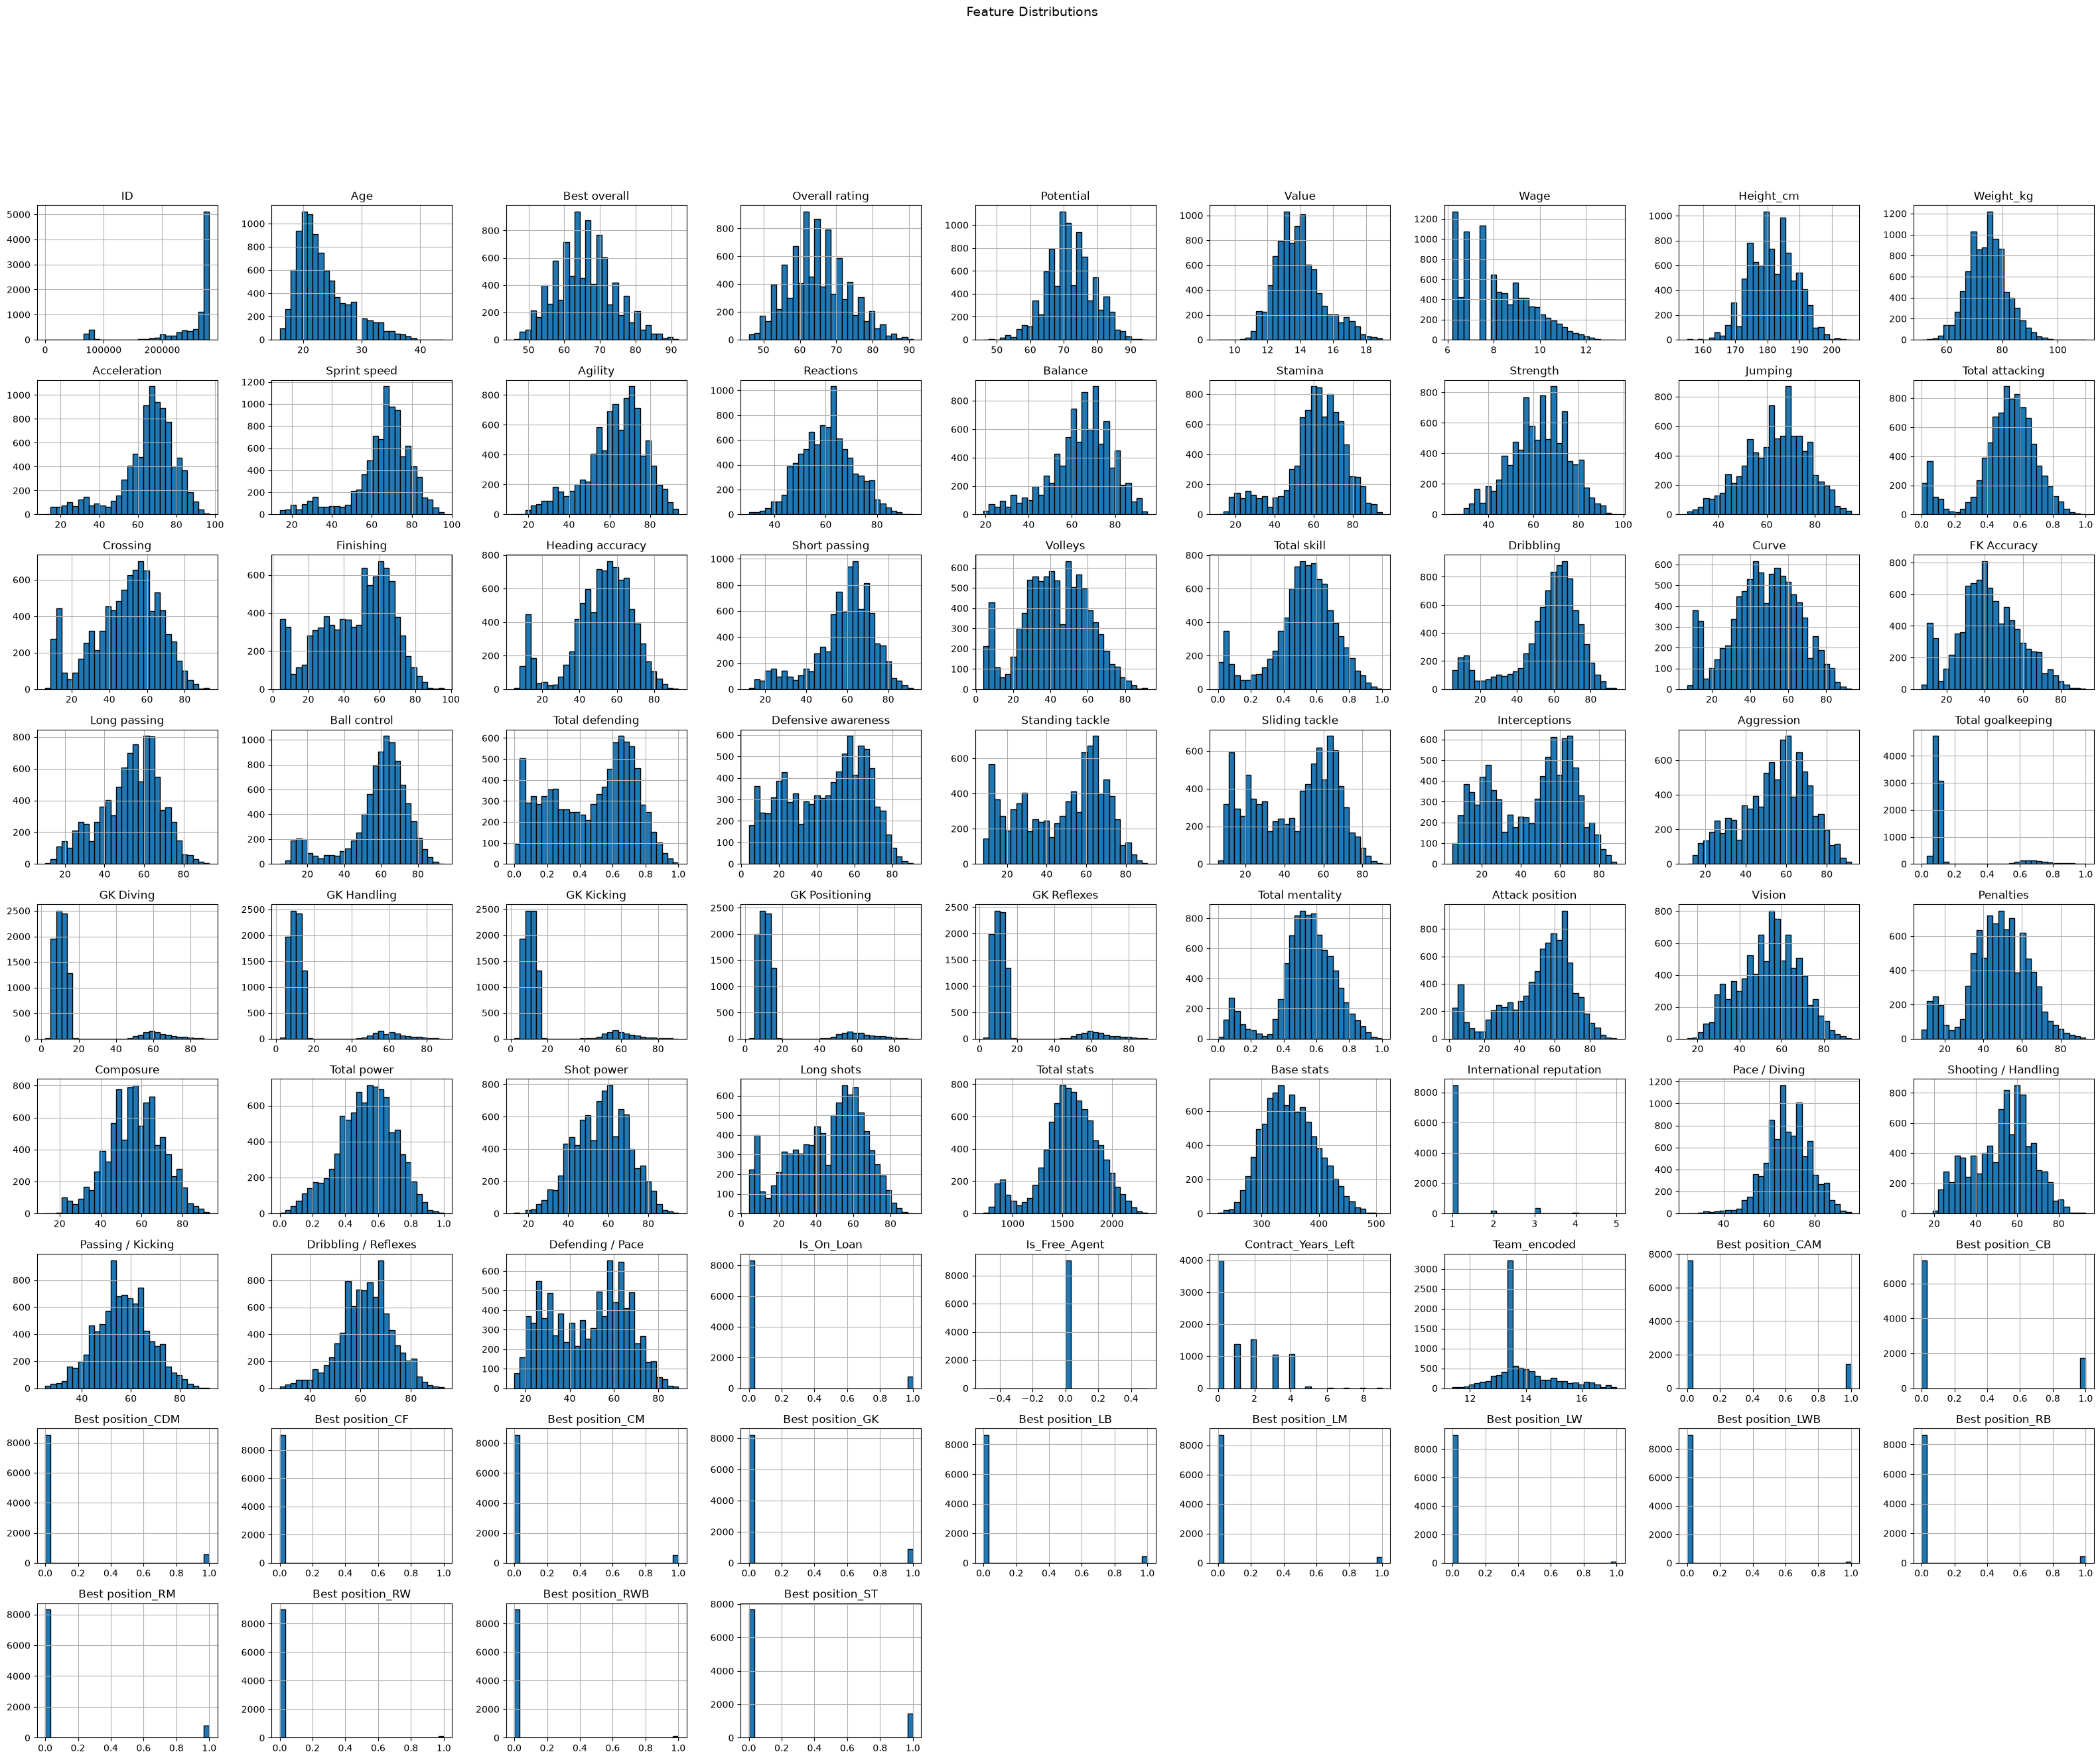

In [54]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(40, 30), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()


In [55]:
df.head()

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST
0,M. Amondarain,74813,20,CM,74,72,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C. Tzolis,256948,23,CAM,82,81,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,R. Ngumoha,80376,16,CAM,73,72,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,K. Adeyemi,251852,23,ST,84,82,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,0.828283,73,81,75,74,71.0,0.786802,84,69.0,62,69,80,0.354839,25,34,49.0,31.0,59,0.095012,12,12,7.0,12,7,0.711172,82.0,74.0,70.0,76.0,0.857576,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,F. Mastantuono,279173,17,CAM,79,77,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


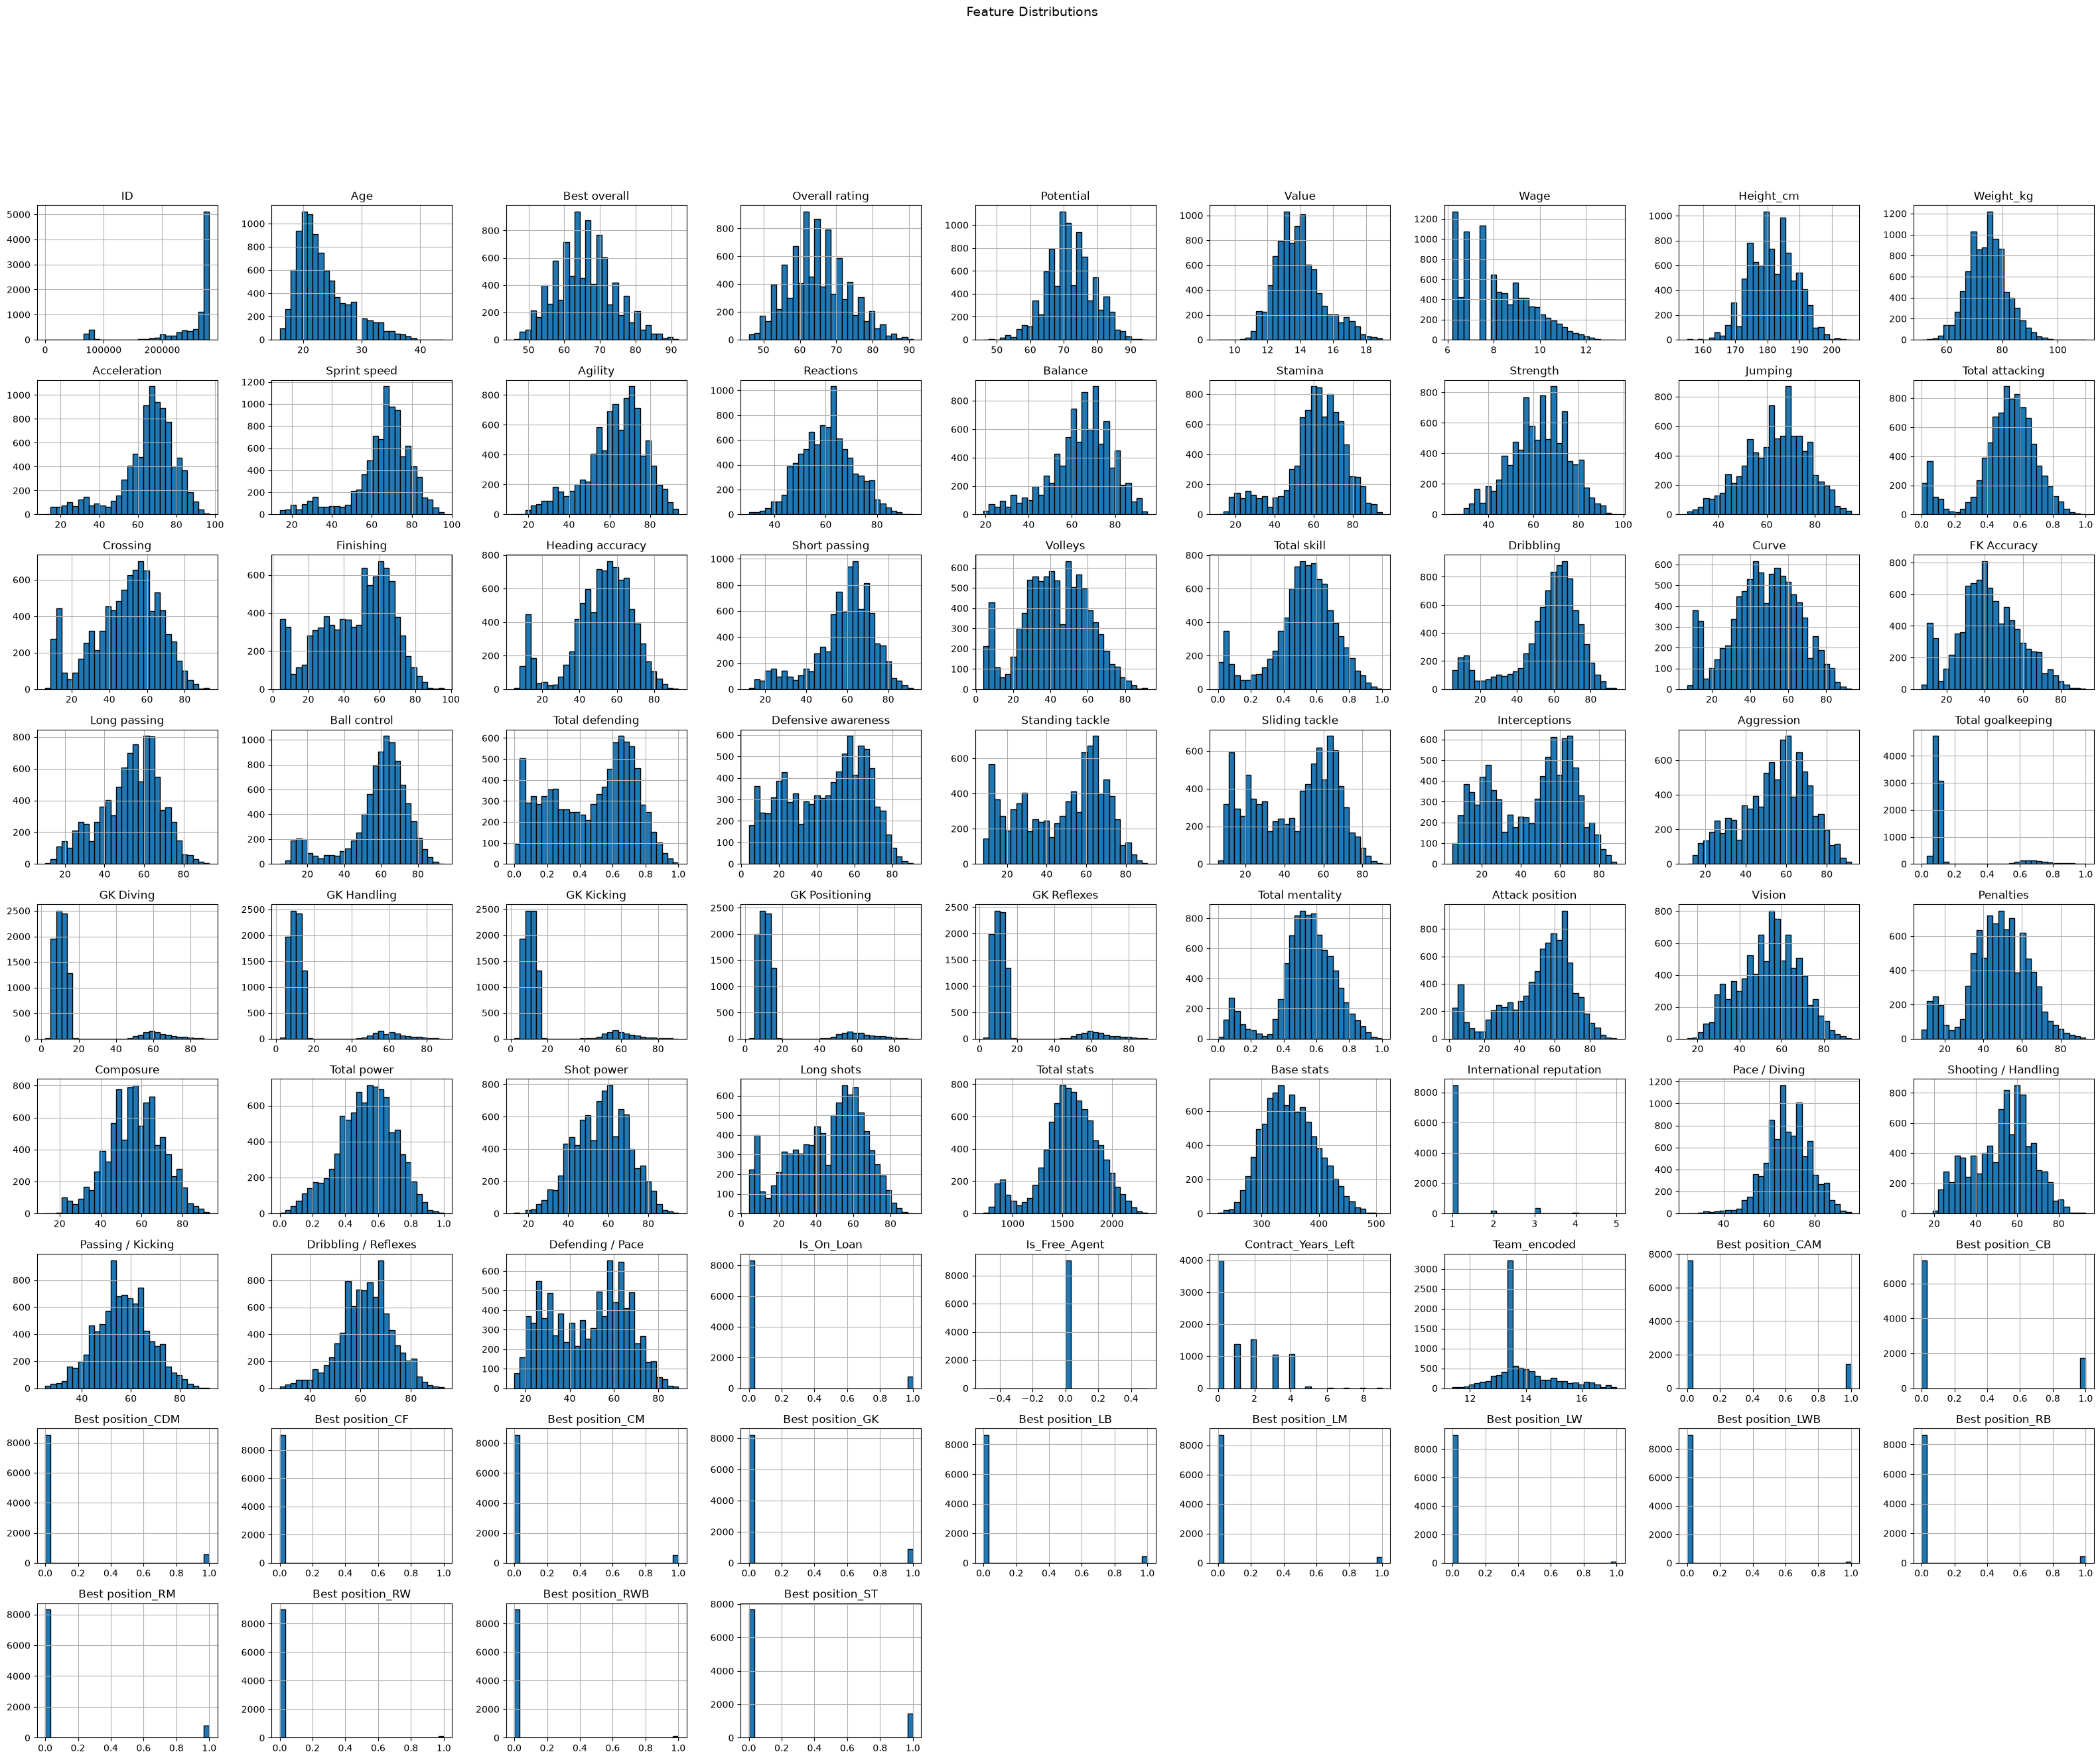

In [56]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(40, 30), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

## 5. Position Based Feature Engineering

right now, best position has many unique values like ST, LW, CM, CB, GK, etc. let's group them into broader categories first, like Attacker, midfielders and defenders

In [57]:
# define position categories
def position_category(pos):
    if pos in ["ST", "CF", "LW", "RW"]:
        return "Forward"
    elif pos in ["CAM", "CM", "CDM", "RM", "LM"]:
        return "Midfielder"
    elif pos in ["CB", "RB", "LB", "RWB", "LWB"]:
        return "Defender"
    elif pos == "GK":
        return "Goalkeeper"
    else:
        return "Other"

# apply function
df["Position Category"] = df["Best position"].apply(position_category)

Here comes the real part when working with features: 
 players in different positions have different key attributes. let's create new features based on this.

In [59]:
df["Forward Score"] = df[["Finishing", "Shot power", "Dribbling", "Acceleration", "Sprint speed"]].mean(axis=1)
df["Midfielder Score"] = df[["Short passing", "Long passing", "Vision", "Ball control", "Stamina"]].mean(axis=1)
df["Defender Score"] = df[["Defensive awareness", "Interceptions", "Standing tackle", "Sliding tackle", "Strength"]].mean(axis=1)
df["Goalkeeper Score"] = df[["GK Diving", "GK Reflexes", "GK Handling", "GK Positioning", "GK Kicking"]].mean(axis=1)

In [60]:
df.sample(10)

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Position Category,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
4874,P. Guiagon,277975,24,CAM,75,74,77,Right,Royal Charleroi Sporting Club,15.607270,9.392745,169,65,76,69,79.0,69,87.0,69,63,63.0,0.679293,70,70,44,71,60.0,0.720812,79,57.0,60,64,78,0.201613,28,20,22.0,26.0,36,0.090261,10,6,7.0,11,14,0.564033,71.0,72.0,57.0,67.0,0.639394,67,65,1740,371,1,72,67,69,78,26,0,0,4,13.794352,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,72.2,70.8,31.8,9.6
9064,25 J. Giménez,269687,21,LM,60,59,71,Left,Sportivo Ameliano,13.217675,8.699681,170,75,73,72,75.0,53,79.0,64,58,54.0,0.525253,49,55,40,57,53.0,0.494924,60,48.0,40,41,60,0.455645,40,45,48.0,18.0,49,0.092637,6,13,10.0,8,12,0.487738,60.0,57.0,50.0,55.0,0.506061,57,50,1554,336,1,72,54,52,62,38,0,0,0,13.010322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,63.4,55.8,41.8,9.8
2998,Héctor Bellerín,203747,30,RB,76,76,76,Right,Real Betis Balompié,15.687313,10.165890,178,74,78,82,72.0,74,78.0,71,60,71.0,0.643939,75,55,58,72,41.0,0.708122,75,69.0,50,64,75,0.794355,69,74,74.0,74.0,69,0.121140,8,14,14.0,13,12,0.776567,67.0,68.0,62.0,70.0,0.548485,52,43,1933,412,3,80,52,69,75,71,0,0,2,15.628673,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Defender,68.4,70.0,70.2,12.2
509,Eduardo Quaresma,252144,23,CB,79,77,84,Right,Sporting CP,16.785925,9.680406,184,79,84,80,68.0,77,70.0,69,77,88.0,0.654040,65,45,72,70,53.0,0.652284,72,62.0,35,68,74,0.870968,78,81,77.0,76.0,75,0.085511,9,13,8.0,8,8,0.741144,65.0,68.0,43.0,77.0,0.742424,67,60,1965,428,1,82,54,66,73,78,0,0,2,16.227666,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Defender,69.6,69.8,77.8,9.2
390,M. Gusto,259307,22,RWB,81,79,84,Right,Chelsea,17.034386,11.407576,178,74,87,81,84.0,76,77.0,85,68,74.0,0.603535,79,32,53,76,45.0,0.761421,77,76.0,50,74,77,0.830645,75,76,75.0,76.0,76,0.092637,10,6,14.0,8,11,0.792916,75.0,74.0,45.0,76.0,0.684848,65,50,2007,430,3,84,46,75,78,73,0,0,4,16.948546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Defender,68.4,77.2,74.0,9.8
128,Casemiro,200145,33,CDM,82,82,82,Right,Manchester United,16.523561,11.512935,185,84,35,36,48.0,82,51.0,68,81,78.0,0.851010,68,69,87,82,77.0,0.809645,68,75.0,70,83,77,0.915323,79,84,84.0,77.0,90,0.135392,13,14,16.0,12,12,0.896458,71.0,80.0,66.0,77.0,0.821212,82,78,2093,417,3,36,74,78,69,81,0,0,3,15.837453,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,58.0,78.0,81.0,13.4
654,Alberto Moreno,205566,32,LB,75,75,75,Left,Como,15.176487,11.097425,171,65,74,75,76.0,75,83.0,75,54,67.0,0.704545,74,65,61,75,50.0,0.736041,74,73.0,55,68,74,0.774194,66,73,73.0,71.0,81,0.104513,10,14,9.0,10,11,0.809264,77.0,69.0,54.0,68.0,0.712121,80,75,2021,423,1,75,69,71,74,69,0,0,3,15.153021,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Defender,73.6,72.2,67.4,10.8
2405,K. Bare,237184,27,CDM,71,71,71,Right,Real Zaragoza,14.403298,8.853808,174,66,65,79,66.0,62

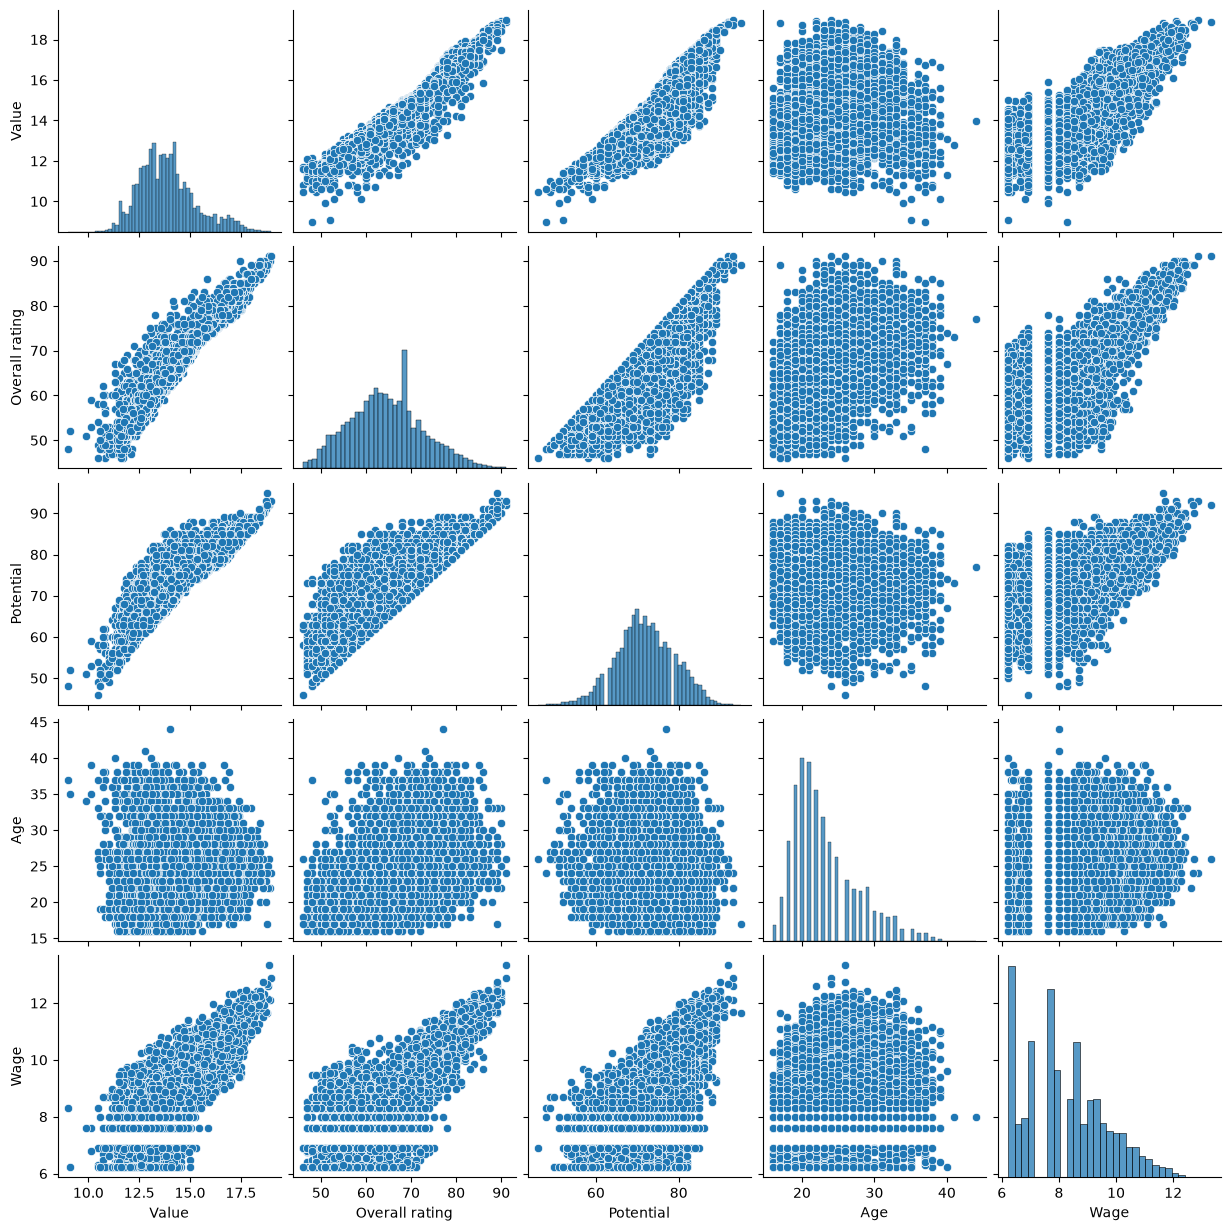

In [61]:
import seaborn as sns

important_features = ['Value', 'Overall rating', 'Potential', 'Age', 'Wage']
sns.pairplot(df[important_features])
plt.show()


C:\Users\sangh\AppData\Local\Temp\ipykernel_6892\1727605754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Best position'], y=df['Value'], palette="coolwarm")


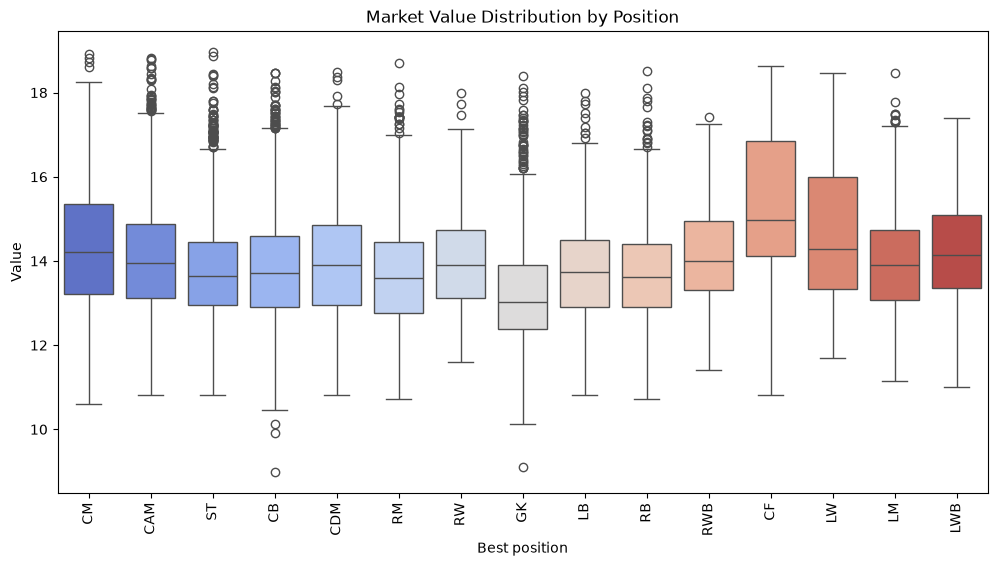

In [62]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Best position'], y=df['Value'], palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Market Value Distribution by Position")
plt.show()


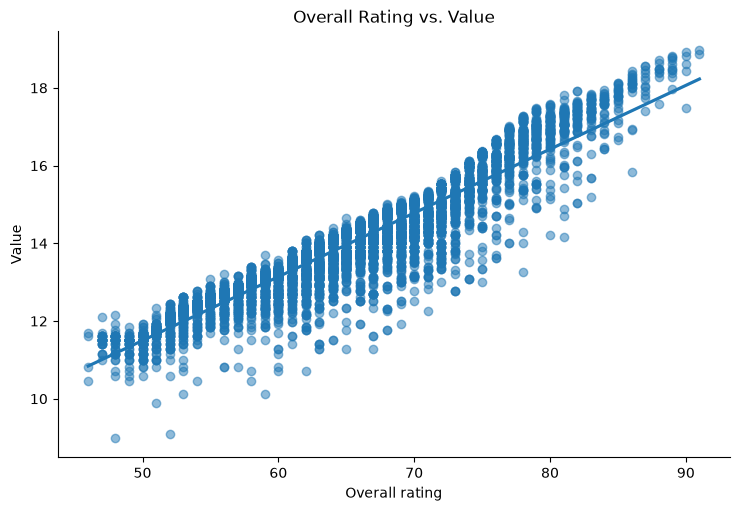

In [63]:
sns.lmplot(x="Overall rating", y="Value", data=df, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Overall Rating vs. Value")
plt.show()


In [64]:
df.sample(5)

,Name,ID,Age,Best position,Best overall,Overall rating,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Position Category,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
1646,B. Goncalves,269288,28,CB,69,69,69,Left,Others,13.997833,8.987322,190,82,68,67,67.0,60,54.0,83,79,78.0,0.467172,51,20,65,69,26.0,0.550761,30,40.0,77,64,60,0.754032,67,70,70.0,67.0,68,0.087886,9,12,12.0,6,8,0.490463,35.0,30.0,35.0,55.0,0.793939,78,60,1685,357,1,67,41,56,47,68,0,0,4,13.429672,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Defender,52.6,61.2,70.6,9.4
1635,B. Raines,269005,20,CDM,65,64,76,Right,New England Revolution,14.077876,7.601402,175,72,74,70,71.0,64,78.0,69,47,53.0,0.452020,44,34,46,73,28.0,0.591371,60,61.0,37,63,66,0.625000,63,58,54.0,62.0,58,0.102138,13,9,9.0,8,14,0.523161,30.0,62.0,35.0,68.0,0.400000,43,36,1592,347,1,72,36,61,64,59,0,0,3,13.621380,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,56.2,66.6,56.8,10.6
4339,26 T. Backwell,278984,22,CAM,59,57,61,Right,Others,12.388398,6.216606,183,78,67,67,72.0,58,70.0,50,49,48.0,0.497475,46,44,46,59,48.0,0.550761,58,51.0,44,59,59,0.544355,50,55,50.0,56.0,73,0.118765,11,15,14.0,9,11,0.640327,51.0,60.0,50.0,54.0,0.378788,54,40,1594,334,1,67,46,55,60,52,0,0,0,13.430423,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,58.0,57.4,52.0,12.0
5159,25 V. Bekaj,277559,27,GK,64,64,67,Right,Hatayspor,13.262127,8.699681,191,82,27,24,35.0,65,24.0,30,62,55.0,0.022727,10,7,12,18,8.0,0.055838,12,15.0,8,27,14,0.048387,6,13,13.0,10.0,27,0.717340,62,63,58.0,63,66,0.122616,3.0,47.0,13.0,42.0,0.242424,44,5,946,338,1,62,63,58,66,26,0,0,0,13.368920,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Goalkeeper,22.8,27.2,20.8,62.4
3997,26 O. Thakura,279457,37,CB,64,64,64,Right,Others,11.512935,6.398595,185,77,58,63,49.0,62,57.0,54,75,68.0,0.404040,32,28,57,57,32.0,0.383249,35,33.0,34,59,44,0.725806,67,66,67.0,66.0,60,0.097387,9,11,6.0,14,11,0.474114,27.0,30.0,46.0,63.0,0.460606,48,23,1448,313,1,61,32,45,43,66,0,0,4,13.430423,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Defender,46.4,48.8,68.2,10.2


In [65]:
df.drop(columns=['Best overall', 'Overall rating'], inplace=True)

In [66]:
df.to_csv("../data/processed/data_after_feature_engineering.csv", index=False)

In [67]:
df.head()

,Name,ID,Age,Best position,Potential,foot,Team,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Reactions,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Position Category,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,M. Amondarain,74813,20,CM,81,Right,Estudiantes de La Plata,15.424949,9.105091,185,75,73,74,71.0,70,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,70.2,74.0,68.2,10.0
1,C. Tzolis,256948,23,CAM,87,Right,Club Brugge KV,17.516813,10.491302,179,73,85,79,84.0,77,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,81.4,79.6,40.4,10.6
2,R. Ngumoha,80376,16,CAM,88,Right,Liverpool,15.607270,10.275086,170,68,92,89,85.0,65,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,79.6,64.8,38.2,9.8
3,K. Adeyemi,251852,23,ST,86,Left,Borussia Dortmund,17.588272,10.859018,180,77,96,96,86.0,82,81.0,77,67,93.0,0.828283,73,81,75,74,71.0,0.786802,84,69.0,62,69,80,0.354839,25,34,49.0,31.0,59,0.095012,12,12,7.0,12,7,0.711172,82.0,74.0,70.0,76.0,0.857576,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Forward,88.6,74.8,41.2,10.0
4,F. Mastantuono,279173,17,CAM,87,Left,Real Madrid,16.906553,11.097425,178,74,79,73,82.0,74,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,75.2,75.8,52.4,9.0
